## "Welcome to the world of AI" 
#### Learning about the Decoder-Only transformer - From scratch with PyTorch .
  
In this third in this series post, we build on what we did in the previous post to now build GPT from scratch. We will leverage Andrej Karpathy Makemore series. https://www.youtube.com/watch?v=kCc8FmEb1nY&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=8.     

Where as Andrej used Tiny shakespare, we will use the baby names dataset that he used in one of his earlier trainings


### Import the libraries

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

### Preparing our hyperparameters for the model

In [28]:
# Let us config a data class
class Config:
    d_model = 16    # The embedding dimensions
    n_heads = 4     # When we get to multi-head attention, we will need this
    d_head = 4      # We could calculate this manually by doing d_model // n_heads
    n_layers = 2    # We are going to stack two layers  
    batch_size = 1  # Batch size of 1
    n_epochs = 1000 # Number of epochs
    lr = 0.01      # Step size of Gradient Descent
    eval_iters = 10 # Evaluate the model every 10 epochs

# instantiate the config 
cfg = Config()

In [29]:
# Let's get our data
with open(file='names.txt', mode='r') as fp:
    text = fp.read()

# Get a sample of the names
print(text[:32])

emma
olivia
ava
isabella
sophia



In [30]:
# Let's build a function to create our vocab
# This is overkill but hey, we should learn to write dry code as much as possible ;-)
def build_vocab(text):
    '''
    text: The full text 
    return:
        chars: The chars in vocabulary
        stoi: maps/encodes characters to numbers
        itos: unmaps/decode numbers back to characters
    '''
    chars = sorted(list(set(text))) # get a list of unique characters in the input text
    stoi = { ch:i for i,ch in enumerate(chars, start=0)} 
    itos = { i:ch for ch,i in stoi.items()}
    return chars, stoi, itos


# Test the function
chars, stoi, itos = build_vocab(text)

print(f'[*] Here are the characters: {chars}')
print(f'[*] Here are the characters: {"".join(chars)}')
print(f'[*] Here is the stoi mapping/encoding: {stoi}')
print(f'[*] Here is the itos un-mapping/decoding: {itos}')

# Setup the vocab size 
vocab_size = len(chars)
print(f'Vocab size / unique tokens: {vocab_size}')

[*] Here are the characters: ['\n', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
[*] Here are the characters: 
abcdefghijklmnopqrstuvwxyz
[*] Here is the stoi mapping/encoding: {'\n': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}
[*] Here is the itos un-mapping/decoding: {0: '\n', 1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z'}
Vocab size / unique tokens: 27


In [31]:
# Take a different view
# Import pandas as pd
import pandas as pd
df = pd.DataFrame(stoi.items(), columns=['char', 'num'])
df.style.hide(axis='index')

char,num
,0
a,1
b,2
c,3
d,4
e,5
f,6
g,7
h,8
i,9


In [32]:
# We do the same thing for the num to strings
df = pd.DataFrame(itos.items(), columns=['num', 'char'])
df.style.hide(axis='index')

num,char
0,
1,a
2,b
3,c
4,d
5,e
6,f
7,g
8,h
9,i


In [33]:
# With above in place, let us setup an encoder function
encode = lambda text, stoi: [ stoi.get(ch) for ch in text ]

# Test the encoder
encode(text='securitynik', stoi=stoi)

[19, 5, 3, 21, 18, 9, 20, 25, 14, 9, 11]

In [34]:
# Similarly setup a decoder
# This maps us back from numbers to chars
decode = lambda indices, itos: ''.join([ itos.get(i) for i in indices ])

# Test the encoder
decode(encode(text='securitynik', stoi=stoi), itos=itos)

'securitynik'

In [35]:
# Setup the tokens from the full text
# This is just us starting the process of converting the entire raw text of baby names 
# into something the computer can use
tokens = torch.tensor(encode(text=text, stoi=stoi), dtype=torch.long)

# This tensor of size: 228145 represents all the characters in text
# that makes up the different baby names
print(f'Here are the tokens: \n{tokens} | tokens dtype: {tokens.dtype} | shape: {tokens.shape} | Dims: {tokens.ndim}')

# If we print the first 3 chars, we se emm
# The last 3 chars are yzx
print(text[:3], text[-3:])

Here are the tokens: 
tensor([ 5, 13, 13,  ..., 25, 26, 24]) | tokens dtype: torch.int64 | shape: torch.Size([228145]) | Dims: 1
emm yzx


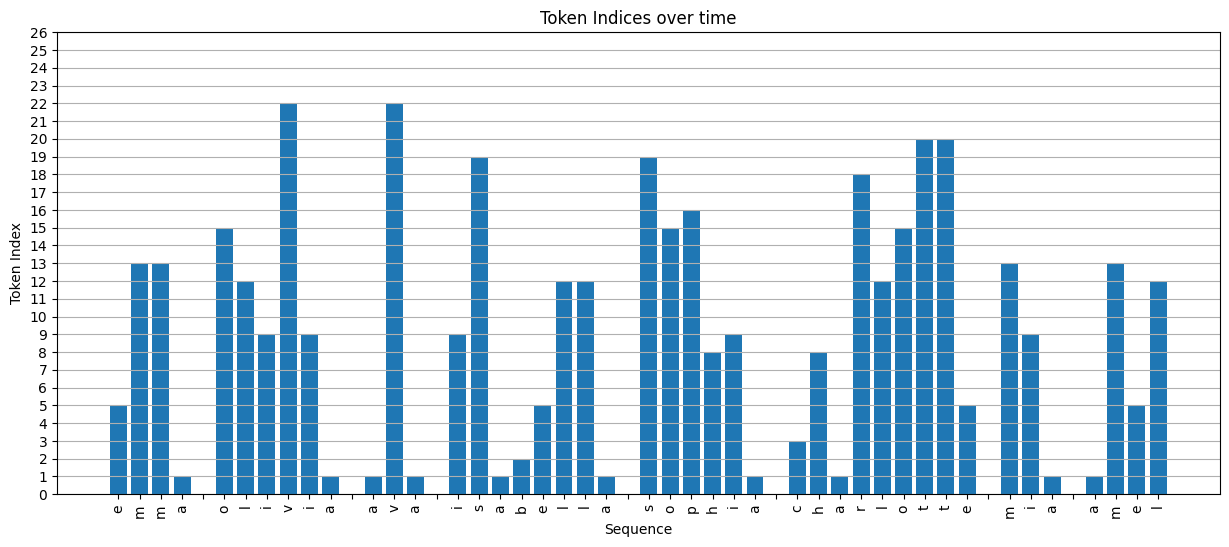

In [36]:
# Let us visualize above
def plot_token_indices(tokens, title='Token Indices over time'):
    '''
    tokens: np.array of shape (B, T)
    '''
    #assert tokens.shape[0] == 1, f'We are working with 1 full row'
    t = torch.arange(50)
    plt.figure(figsize=(15,6))
    plt.title(title)
    plt.bar(x=t, height=tokens[:t.max()+1])
    plt.xticks(ticks=range(0, len(t),1), labels=text[:len(t)], rotation=90)
    plt.yticks(ticks=range(0,len(chars),1))
    plt.ylabel('Token Index')
    plt.xlabel('Sequence')
    plt.grid(axis='y')
    plt.show()

# Test the function
plot_token_indices(tokens=tokens)

In [37]:
# As with all machine learning
# we generally split our data into train and test sets
# or train, test and validation split
# we will have train and test sets

# We will use 90% of the data for training
n = int(len(text) * 0.9)

# This is our train data
X_train = tokens[:n]
print(f'Train data shape: **{X_train.shape}**')

# The remainder will be our test data
# This is how we will test the model's performance
X_test = tokens[n:]
print(f'Test data shape: **{X_test.shape}**')

Train data shape: **torch.Size([205330])**
Test data shape: **torch.Size([22815])**


In [38]:
# Now that we have our tokens for training and testing, 
# let us setup our context window
# The context window is the maximum number of tokens the model 
# can use to predict/generate the next token.
# In this case our model is character based
# Therefore we want to predict the next character
# We will sample random of tokens up to length context_window_length

context_window_length = 8

In [39]:
# Before adding the data,let us understand our objective
# for X_train, we want to go up to context length
# This is the input
print(X_train[:context_window_length])

# For the y_train, we want to go index + 1
# These are the targets
print(X_train[1:context_window_length + 1])

tensor([ 5, 13, 13,  1,  0, 15, 12,  9])
tensor([13, 13,  1,  0, 15, 12,  9, 22])


What do we take away from the output? Note this is in context of the data above only, we want when the input is 6, the target as in the value to predict is 14. When the input is 6,14, the model should predict 14. When the input is 6,14,14 the model should predict 2. .... Until in this case, when we get to  6, 14, 14,  2,  1, 16, 13, 10, the model should predict 23

In these examples, the model is learning multiple combinations of the input as it predicts the targets. The model should be able to learn context from as little as one up to context length, to be able to predict context_window_length + 1 So rather than only given up to - in this case - 8 characters, we can give as little as one and get the model to predict what comes next. If for some reason you have more characters than context_window_length, then the model should truncate your data up to context_window_length.   

Let us now take what we learned above, to start preparing our data for the transformer. At this point, we have T (time dimension), we need to get the batch dimension also, so we can put multiple rows in at one time.

In [40]:
# Let's use a batch size of 4 sample at a time
# Just using 4 to keep our view cleaner and easier as we move through
# I thought about 8 but when you see (8,8) for (B, T) vs (4, 8), I think (4,8) is a little easier to understand
batch_size = 4

# setup a small function to generate that batches
def generate_batch(X, batch_size=batch_size):
    '''
    X: input data (T)
    batch_size: int (B)

    Returns:
        (B, T)
    '''
    
    # Setup some random indices to sample from
    # This will be 0 to the number of items in X - context_window_length
    # context_window_length is currently 8
    # This will generate 8 random values
    idx = torch.randint(low=0, high=len(X) - context_window_length, size=(batch_size,))

    # Use those random values to get our X_batch
    # Once we have each of the batches
    # create a new dimension B and stack them vertically
    X_batch = torch.stack(tensors=[ X[i:i + context_window_length] for i in idx], dim=0)

    # With the X_batch in place, let's get the targets -> y_batch
    # We will reuse above with a small tweak
    y_batch = torch.stack(tensors=[ X[i+1:i + context_window_length + 1] for i in idx], dim=0)
    
    # Let's return or X_batch and y_batch
    return (X_batch, y_batch)


In [41]:
# Test the function
X_tmp, y_tmp = generate_batch(X=X_test)

print(f'Here is X_tmp has shape: {X_tmp.size()}: \n{X_tmp}')

# print the y_tmp
print(f'\nHere is y_tmp has shape: {y_tmp.size()}: \n{y_tmp}')

Here is X_tmp has shape: torch.Size([4, 8]): 
tensor([[12,  9, 21, 19,  0,  1, 12,  9],
        [ 3,  1, 19, 13,  9, 18,  0,  3],
        [26,  5,  5, 26,  0,  1,  2,  4],
        [12,  9,  5, 12,  0, 11,  1, 12]])

Here is y_tmp has shape: torch.Size([4, 8]): 
tensor([[ 9, 21, 19,  0,  1, 12,  9, 26],
        [ 1, 19, 13,  9, 18,  0,  3,  1],
        [ 5,  5, 26,  0,  1,  2,  4, 21],
        [ 9,  5, 12,  0, 11,  1, 12,  9]])


What do you take away from above? 
First we have 8 rows (B). 
This is our batch size of 8   
You see this shape/size in both the X_tmp and y_tmp

Let us take the first row in X_tmp and the correcting first row in y_tmp. This is the first batch of 8 tokens in the (1,T).  
Note my explanation below is in context of the output above. We 

When the model see 1 in X_tmp, we would like it to predict 4. When the model has input X_tmp of 1,4, we would like it to predict 16. Similarly, when the model sees 1,4,16, we would like it to predict 5. As you can see, this is much like what we discussed earlier. Difference being now that we have the batch of 8 items.  

With our data, let us start building our model from scratch


In [42]:
# Let us build a single head attention mechanism
# We are not going to use this in the end but are building up
# Because it is a single head, we will use d_model as the head size

class SingleHeadAttention(nn.Module):
    ''' Single attention head'''
    def __init__(self, ):
        super(SingleHeadAttention, self).__init__()

        # Setup our three projection matrices
        # The bias is usually disabled, so only W @ X not W @ X + b
        self.query = nn.Linear(in_features=cfg.d_model, out_features=cfg.d_model, bias=False)
        self.key = nn.Linear(in_features=cfg.d_model, out_features=cfg.d_model, bias=False)
        self.values = nn.Linear(in_features=cfg.d_model, out_features=cfg.d_model, bias=False)
    
        # Setup our triangular matrix for the mask
        self.register_buffer('tril', torch.tril(torch.ones(context_window_length, context_window_length)))
    
    def forward(self, x):
        # x (B, T, d_model)
        # Capture that shape information
        B, T, D = x.size()

        # project the x into the query, keys and values
        Q = self.query(x)   # (B, T, d_model)
        K = self.key(x)     # (B, T, d_model)
        V = self.values(x)  # (B, T, d_model)

        # calculate our attention scores
        # Q has shape (B, d_model, d_model) and K has shape ((B, d_model, d_model))
        attn_scores = Q @ K.transpose(-2, -1) # (B, T, T)

        # scale the scores 
        scaled_attn_scores = attn_scores / cfg.d_model**.5 # (B, T, T)

        # Add the mask
        masked_scores = scaled_attn_scores.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # (B, T, T)

        # Get the weights via softmax
        attn_weights = F.softmax(masked_scores, dim=-1) # (B, T, T)
        
        # Get the seighted sum of the values
        attn_out = attn_weights @ V # (B, T, d_model)

        return attn_out

# Test the class
single_head_attention = SingleHeadAttention()

# Create one batch of dummy data to test our model
# We assume this is our input embeddings (token + position)
tmp_x = torch.rand((1, context_window_length, cfg.d_model))
out_single_head_attention = single_head_attention(tmp_x)
out_single_head_attention.shape

torch.Size([1, 8, 16])

With confirmation that above works, we could plug this into our model below. Note this will be replaced but I will leave the line commented out when we get to our multi-head attention.

That head_size parameter above is temporary. We will determine the head_size automatically, once we know the number of heads. Anyhow, this still works for now

The Transformer architecture also has a Feed Forward Network. Let's implement that


In [43]:
# Setup the feed forward network
class FeedForward(nn.Module):
    '''The linear layer for the transformer decoder block '''
    def __init__(self, hidden_dim=cfg.d_model*4):
        super(FeedForward, self).__init__()

        # This operation is being performed on a per token basis
        # it is also being done independently
        self.net = nn.Sequential(
            nn.Linear(in_features=cfg.d_model, out_features=hidden_dim),
            nn.GELU(),
            nn.Linear(in_features=hidden_dim, out_features=cfg.d_model)
        )

    def forward(self, x):
        return self.net(x)  # (B, T, d_model)

# Test the function
ffn = FeedForward()
ffn(out_single_head_attention).shape

torch.Size([1, 8, 16])

In [44]:
# knowing that our FFN is working, 
# let us put together a multi-head attention

class MultiHeadAttention(nn.Module):
    def __init__(self, n_heads, d_model):
        super(MultiHeadAttention, self).__init__()
        assert cfg.d_model % n_heads == 0, f'd_model: {cfg.d_model} is not divisible by number of heads: {n_heads}'

        # Get the head dimensions
        # For out demo, this gives us 4 heads
        self.n_heads = n_heads
        self.d_head = cfg.d_model // n_heads
        self.d_model = d_model

        # We use one One matrix for the QKV that we will then split
        # We have *3 because it is the q, k, v
        self.W_qkv_proj = nn.Linear(in_features=d_model, out_features=3*d_model, bias=False)

        # Setup the final linear layer to fuse the data after concatenating the head
        self.W_out_proj = nn.Linear(in_features=d_model, out_features=d_model, bias=False)

        # Whereas in the single head we registered the buffer, we will instead use pytorch built in tools to get the mask


    def forward(self, x):
        # x: (B, T, d_model)
        # Capture those shapes
        B, T, D = x.size()

        # Do our first linear projection
        qkv = self.W_qkv_proj(x) # (B, T, 3*d_model)

        # Get our qkv
        qkv = qkv.view(B, T, 3, self.n_heads, self.d_head) # (B, T, 3, n_heads, d_head)

        # Reshape qkv, so we can extract each of the 3 matrices
        qkv = qkv.permute(2, 0, 3, 1, 4) # (3, B, n_heads, T, d_model)

        # Finally extract the Q, K, V
        # Each of these now have (B, n_heads, T, d_head)
        Q, K, V = qkv[0], qkv[1], qkv[2]

        # Rather than building the mask like we did previously,
        # Let's leverage Torch's efficient implementation of the scaled dot product attention. 
        # https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html

        attn_output = F.scaled_dot_product_attention(
            query=Q, key=K, value=V, # Our Q, K, V
            attn_mask=None, # No explicit mask needed
            dropout_p=0.0,   # Disable dropout
            is_causal=True,  # Applies lower triangular causal mask
        )   # (B, n_heads, T, d_head)

        # Transpose the attn_output
        # I just use permute her to do something different
        # Let us also ensure we have a contiguous tensor in memory
        attn_output = attn_output.permute(0, 2, 1, 3).contiguous() # (B, T, n_heads, d_head)

        # Reshape now, so that we consolidate back to (B, T, d_model)
        attn_output = attn_output.view(B, T, self.d_model) #(B, T, d_model)

        # Wrap this up with the final project where we fuse the outputs
        out = self.W_out_proj(attn_output)
        
        return out

# Test the function
multihead_self_attention = MultiHeadAttention(n_heads=4, d_model=cfg.d_model)

# Looks like our multi-head attention mechanism is working as expected
multihead_self_attention(tmp_x).shape

torch.Size([1, 8, 16])

In [45]:
# Setup a block now that we have the major ingredients in place
class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads):
        super(DecoderBlock, self).__init__()
        # Setup two layer norms
        self.ln1 = nn.LayerNorm(normalized_shape=d_model)
        self.ln2 = nn.LayerNorm(normalized_shape=d_model)

        # Multi-head attentions
        self.mha = MultiHeadAttention(n_heads=n_heads, d_model=d_model)

        # Feedforward
        self.ffn = FeedForward(hidden_dim=d_model*4)
    def forward(self, x):
        # Let's leverage residual connection here 
        # We perform layer normalization before passing the input
        # to self-attention
        # by adding the input to the output 

        x = x + self.mha(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

# Test the function
decoder_block = DecoderBlock(d_model=cfg.d_model, n_heads=4)
decoder_block(tmp_x).shape

torch.Size([1, 8, 16])

In [46]:
# implement a class
class BabyNamesModel(nn.Module):
    # Setup our constructor
    def __init__(self, d_model, n_heads):
        # we will inherit from the nn.Module class
        super(BabyNamesModel, self).__init__()

        # Let's setup our embeddings (lookup) table
        # We have 27 unique chars/tokens in our vocab
        # the embedding_dim is the width of our embedding vector
        self.token_embeddings = nn.Embedding(num_embeddings=vocab_size, embedding_dim=d_model)

        # Setup the position embeddings
        # The transformer processes data in parallel
        # thus position/order information is lost
        # Positional embeddings are used to preserve the order
        # This gives every positions its own embedding vector
        self.pos_embeddings = nn.Embedding(num_embeddings=context_window_length, embedding_dim=d_model)

        # Here we use our single attention head
        # self.single_attention_head = SingleHeadAttention()

        # Once we have our multi-head attention, we can comment out the single_attention_head
        # and leverage multi_head
        #self.mha = MultiHeadAttention(n_heads=n_heads, d_model=d_model)

        # Let's add our FFN
        #self.ffn = FeedForward(hidden_dim=d_model * 4)

        # Setup the Decoder Block:
        # Test with one to start
        # self.decoder_block = DecoderBlock(d_model=d_model, n_heads=n_heads)

        # With the decoder block working stack them
        # Let us use blocks
        self.decoder_block = nn.Sequential(
            DecoderBlock(d_model=d_model, n_heads=n_heads),
            DecoderBlock(d_model=d_model, n_heads=n_heads),
            DecoderBlock(d_model=d_model, n_heads=n_heads),
            DecoderBlock(d_model=d_model, n_heads=n_heads),
            nn.LayerNorm(normalized_shape=d_model),
        )

        # Setup the language model head
        self.lm_head = nn.Linear(in_features=d_model, out_features=vocab_size)


    def forward(self, x):
        # x: (B, T)

        # Let's extract those dimensions
        B, T = x.size()

        # Apply the token embeddings 
        tok_embd = self.token_embeddings(x) # (B, T, d_model)

        # Apply the position embeddings
        pos_embd = torch.arange(T) # (T)
        pos_embd = self.pos_embeddings(pos_embd) # (T, d_model)

        # Add the token and positional embeddings to create our first residual
        # Our x here now holds both the token identities and their positions
        x = tok_embd + pos_embd # (B, T, d_model)

        # Apply the single attention head
        #x = self.single_attention_head(x) # (B, T, d_model)

        # Similarly, comment out above
        # Now that we have our Multihead attention
        #x = self.mha(x)

        # Apply the FFN
        #x = self.ffn(x)

        x = self.decoder_block(x)

        # Add the language model head
        logits = self.lm_head(x) # (B, T, vocab_size)

        return logits

# Test the class
model = BabyNamesModel(n_heads=4, d_model=cfg.d_model)

# We test on our X_tmp for now.
# Later we will use our train data properly
model(x=X_tmp).shape

torch.Size([4, 8, 27])

In [47]:
# Setup the optimizer
optimizer = torch.optim.AdamW(params=model.parameters(), lr=cfg.lr)
optimizer

# Setup our loss function
loss_fn = nn.CrossEntropyLoss(reduction='mean')
loss_fn

CrossEntropyLoss()

In [48]:
print('Training ...')

# Setup the training loop
for epoch in range(cfg.n_epochs):
    X, y = generate_batch(X_train)
    # print(X)
    # print(y)

    # Zero out the gradients
    optimizer.zero_grad(set_to_none=True)
    
    # Get the predictions for the batch
    y_pred = model(X)   # (B, T, vocab_size)
    
    # Need to reshape y_pred to (B*T, vocab_size) 
    # be able to use crossentropy loss 
    y_pred = y_pred.view(-1, vocab_size)

    # We also need to reshape y which is currently (B, T) to (B*T)

    # Now calculate the loss
    loss = loss_fn(input=y_pred, target=y.view(-1))
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f'[*] Epoch: {epoch + 1} | Loss: {loss.item()}')

    #if epoch == 10:
    #    break

Training ...
[*] Epoch: 1 | Loss: 3.434722661972046
[*] Epoch: 101 | Loss: 2.5095694065093994
[*] Epoch: 201 | Loss: 2.4064576625823975
[*] Epoch: 301 | Loss: 2.75
[*] Epoch: 401 | Loss: 2.5076470375061035
[*] Epoch: 501 | Loss: 2.2398200035095215
[*] Epoch: 601 | Loss: 2.3514010906219482
[*] Epoch: 701 | Loss: 2.4178991317749023
[*] Epoch: 801 | Loss: 2.4841392040252686
[*] Epoch: 901 | Loss: 2.4126663208007812


In [50]:
# Let's generate some names
def generate_baby_names(batch_size=4):
    for _ in range(batch_size):
        # is our current batch, our current context
        X, _ = generate_batch(X=X_train, batch_size=16) # (B, T)

        # We are ensuring that the input is never greater than the context_window_length
        # If we go beyond context_window_length
        # The position embedding table will run out of scope 
        # as we only have positions for up to context_window_length
        idx_cond = X[:, -context_window_length:] # (B, T)
        
        # Get the logits from the model
        logits = model(idx_cond)    # (B, T, d_model)

        # Focus on the last time step
        logits = logits[:, -1, :] # (B, vocab_size)

        # Get the probabilities of the next token
        probs = F.softmax(logits, dim=-1) # (B, vocab_size)

        # Sample from the model
        idx_next = torch.multinomial(input=probs, num_samples=1, replacement=False) 

        # Concatenate the 
        idx = torch.cat((X, idx_next), dim=1)

    return idx

# Test the function
tmp_idx = generate_baby_names(batch_size=10).tolist()
tmp_idx

[[2, 18, 9, 25, 1, 0, 2, 18, 25],
 [14, 0, 19, 21, 8, 1, 14, 0, 12],
 [0, 1, 4, 25, 12, 25, 14, 14, 1],
 [6, 18, 1, 14, 11, 5, 5, 0, 5],
 [1, 19, 8, 13, 5, 18, 5, 0, 26],
 [5, 0, 8, 15, 12, 12, 25, 14, 0],
 [18, 5, 5, 0, 12, 1, 11, 5, 22],
 [18, 9, 1, 14, 1, 0, 10, 1, 8],
 [12, 21, 26, 9, 1, 14, 1, 0, 13],
 [0, 4, 1, 18, 9, 5, 12, 12, 0],
 [18, 1, 2, 5, 12, 12, 5, 0, 8],
 [0, 18, 15, 19, 1, 12, 9, 14, 20],
 [9, 14, 5, 0, 9, 19, 1, 2, 1],
 [12, 12, 1, 18, 25, 0, 13, 1, 12],
 [1, 18, 0, 3, 1, 13, 5, 12, 12],
 [1, 25, 14, 5, 0, 2, 12, 5, 12]]

In [ ]:
# Generate some names from above
print(''.join([itos[j] for i in tmp_idx for j in i]))


saia
savisa
lawsion
rionana
nyasiablegend
creson
burl
dmoni
dlh
kendahdyson
tysdyden
zeloen
deeja
am
jaxyna
jalal
jaernan
jabkeslynn
oelie
zofl


Well that's it for this post. See you in the final post where we wrap this all up.